# XGBOOST/LSTM

In [2]:
# Importer les bibliothèques nécessaires
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense



## Téléchargement et traitement des données pour les 7 derniers jours

In [12]:

def data_court_terme(t):
  ticker = yf.Ticker(t)
  var = ticker.history(period="7d", interval="1m")
  var.to_csv(r"/content/drive/MyDrive/Colab Notebooks/PPE/" + t + "_ct.csv")

  df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/PPE/" + t + "_ct.csv")

  df["Datetime"] = pd.to_datetime(df["Datetime"])

  df["Hour"] = df["Datetime"].dt.hour
  df["Minute"] = df["Datetime"].dt.minute
  df["Day"] = df["Datetime"].dt.dayofweek


  df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 7)
  df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 7)

  df["Minute_sin"] = np.sin(2 * np.pi * df["Minute"] / 7)
  df["Minute_cos"] = np.cos(2 * np.pi * df["Minute"] / 7)

  df["Day_sin"] = np.sin(2 * np.pi * df["Day"] / 5)
  df["Day_cos"] = np.cos(2 * np.pi * df["Day"] / 5)

  df = df.drop(columns = ["Hour", "Minute", "Day", "Dividends", "Stock Splits"])


  def RSI(df, period):
      """
      Add a Relative Strength Index column to a DataFrame

      Parameters:
      df : pandas DataFrame

      Returns:
      df_rsi : pandas DataFrame with an additional "RSI" column
      """
      # Calculate the daily change in closing price
      df['dif'] = df['Close'].diff()

      # Separate gains and losses
      df['gain'] = df['dif'].where(df['dif'] > 0, 0)
      df['loss'] = -df['dif'].where(df['dif'] < 0, 0)

      # Calculate the average gains and losses
      df['avg_gain'] = df['gain'].rolling(window=period, min_periods=1).mean()
      df['avg_loss'] = df['loss'].rolling(window=period, min_periods=1).mean()

      # Calculate the relative strength
      df['RS'] = df['avg_gain'] / df['avg_loss']

      # Calculate the RSI
      df['RSI'] = 100 - (100 / (1 + df['RS']))

      # Drop intermediate columns to keep the DataFrame clean
      df_rsi = df.drop(columns=['dif', 'gain', 'loss', 'avg_gain', 'avg_loss', 'RS'])

      return df_rsi


  df = RSI(df, 14)

  def PPO(df, short_period=12, long_period=26):
      """
      Add a PPO column to a DataFrame

      Parameters:
      df : pandas DataFrame
      short_period : The short period for the EMA calculation
      long_period : The long period for the EMA calculation

      Returns:
      df_ppo : pandas DataFrame with an additional "PPO" column
      """
      # Calculate the short-term EMA
      df['ema_short'] = df['Close'].ewm(span=short_period, adjust=False).mean()

      # Calculate the long-term EMA
      df['ema_long'] = df['Close'].ewm(span=long_period, adjust=False).mean()

      # Calculate the PPO
      df['PPO'] = ((df['ema_short'] - df['ema_long']) / df['ema_long']) * 100

      # Drop intermediate columns
      df_ppo = df.drop(columns=['ema_short', 'ema_long'])

      return df_ppo


  df = PPO(df)



  def MACD(df, short_period=12, long_period=26, signal_period=9):
      """
      Add a MACD column to a DataFrame

      Parameters:
      df : pandas DataFrame
      short_period : The short period for the MACD calculation
      long_period : The long period for the MACD calculation
      signal_period : The period for the signal line

      Returns:
      df_macd : pandas DataFrame with additional "MACD" and "Signal" columns
      """
      # Calculate the short-term exponential moving average (EMA)
      df['ema_short'] = df['Close'].ewm(span=short_period, adjust=False).mean()

      # Calculate the long-term exponential moving average (EMA)
      df['ema_long'] = df['Close'].ewm(span=long_period, adjust=False).mean()

      # Calculate the MACD line
      df['MACD'] = df['ema_short'] - df['ema_long']

      # Calculate the signal line
      df['Signal'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()

      # Drop intermediate columns
      df_macd = df.drop(columns=['ema_short', 'ema_long'])

      return df_macd

  df = MACD(df)

  def OBV(df):
      """
      Add an On-Balance Volume column to a DataFrame

      Parameters:
      df : pandas DataFrame

      Returns:
      df_obv : pandas DataFrame with an additional "OBV" column
      """
      # Determine the price direction
      df['direction'] = (df['Close'] > df['Close'].shift(1)).astype(int) * 2 - 1
      df['direction'].iloc[0] = 0  # Set the direction of the first row to 0

      # Calculate the daily OBV change
      df['obv_change'] = df['direction'] * df['Volume']

      # Compute the cumulative OBV
      df['OBV'] = df['obv_change'].cumsum()

      # Drop intermediate columns
      df_obv = df.drop(columns=['direction', 'obv_change'])

      return df_obv


  df = OBV(df)


  def ROC(df, period):
      """
      Add a Rate of Change column to a DataFrame

      Parameters:
      df : pandas DataFrame
      period : The period over which the ROC is calculated

      Returns:
      df_roc : pandas DataFrame with an additional "ROC" column
      """
      # Calculate the price 'period' periods ago
      df['Close_period'] = df['Close'].shift(period)

      # Calculate the Rate of Change
      df['ROC'] = ((df['Close'] - df['Close_period']) / df['Close_period']) * 100

      # Drop intermediate columns
      df_roc = df.drop(columns=['Close_period'])

      return df_roc

  df = ROC(df, 14)

  df["RSI"] = df["RSI"].fillna(df["RSI"].mean())
  df["ROC"] = df["ROC"].fillna(df["ROC"].mean())
  df = df.rename(columns={"Datetime": "Date"})
  return df


## Téléchargement et traitement des données pour une période de 15 ans

In [10]:
def data_long_terme(t):
  var = yf.download(t, start = "2010-03-09", end= "2025-04-01", multi_level_index = False)
  var.to_csv(r"/content/drive/MyDrive/Colab Notebooks/PPE/" + t + "_lt.csv")

  df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/PPE/" + t + "_lt.csv")
  df=df.rename(columns= {"Date": "Datetime"})
  df["Datetime"] = pd.to_datetime(df["Datetime"])

  # Données temporelles en encodage cyclique pour capturer les motifs
  df["DayOfWeek"] = df["Datetime"].dt.dayofweek
  df["Month"] = df["Datetime"].dt.month

  df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
  df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
  df["Day_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 5)
  df["Day_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 5)

  df = df.drop(columns = ["Month", "DayOfWeek"])


  def RSI(df, period):
      """
      Add a Relative Strength Index column to a DataFrame

      Parameters:
      df : pandas DataFrame

      Returns:
      df_rsi : pandas DataFrame with an additional "RSI" column
      """
      # Calculate the daily change in closing price
      df['dif'] = df['Close'].diff()

      # Separate gains and losses
      df['gain'] = df['dif'].where(df['dif'] > 0, 0)
      df['loss'] = -df['dif'].where(df['dif'] < 0, 0)

      # Calculate the average gains and losses
      df['avg_gain'] = df['gain'].rolling(window=period, min_periods=1).mean()
      df['avg_loss'] = df['loss'].rolling(window=period, min_periods=1).mean()

      # Calculate the relative strength
      df['RS'] = df['avg_gain'] / df['avg_loss']

      # Calculate the RSI
      df['RSI'] = 100 - (100 / (1 + df['RS']))

      # Drop intermediate columns to keep the DataFrame clean
      df_rsi = df.drop(columns=['dif', 'gain', 'loss', 'avg_gain', 'avg_loss', 'RS'])

      return df_rsi


  df = RSI(df, 14)

  def PPO(df, short_period=12, long_period=26):
      """
      Add a PPO column to a DataFrame

      Parameters:
      df : pandas DataFrame
      short_period : The short period for the EMA calculation
      long_period : The long period for the EMA calculation

      Returns:
      df_ppo : pandas DataFrame with an additional "PPO" column
      """
      # Calculate the short-term EMA
      df['ema_short'] = df['Close'].ewm(span=short_period, adjust=False).mean()

      # Calculate the long-term EMA
      df['ema_long'] = df['Close'].ewm(span=long_period, adjust=False).mean()

      # Calculate the PPO
      df['PPO'] = ((df['ema_short'] - df['ema_long']) / df['ema_long']) * 100

      # Drop intermediate columns
      df_ppo = df.drop(columns=['ema_short', 'ema_long'])

      return df_ppo


  df = PPO(df)



  def MACD(df, short_period=12, long_period=26, signal_period=9):
      """
      Add a MACD column to a DataFrame

      Parameters:
      df : pandas DataFrame
      short_period : The short period for the MACD calculation
      long_period : The long period for the MACD calculation
      signal_period : The period for the signal line

      Returns:
      df_macd : pandas DataFrame with additional "MACD" and "Signal" columns
      """
      # Calculate the short-term exponential moving average (EMA)
      df['ema_short'] = df['Close'].ewm(span=short_period, adjust=False).mean()

      # Calculate the long-term exponential moving average (EMA)
      df['ema_long'] = df['Close'].ewm(span=long_period, adjust=False).mean()

      # Calculate the MACD line
      df['MACD'] = df['ema_short'] - df['ema_long']

      # Calculate the signal line
      df['Signal'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()

      # Drop intermediate columns
      df_macd = df.drop(columns=['ema_short', 'ema_long'])

      return df_macd

  df = MACD(df)

  def OBV(df):
      """
      Add an On-Balance Volume column to a DataFrame

      Parameters:
      df : pandas DataFrame

      Returns:
      df_obv : pandas DataFrame with an additional "OBV" column
      """
      # Determine the price direction
      df['direction'] = (df['Close'] > df['Close'].shift(1)).astype(int) * 2 - 1
      df['direction'].iloc[0] = 0  # Set the direction of the first row to 0

      # Calculate the daily OBV change
      df['obv_change'] = df['direction'] * df['Volume']

      # Compute the cumulative OBV
      df['OBV'] = df['obv_change'].cumsum()

      # Drop intermediate columns
      df_obv = df.drop(columns=['direction', 'obv_change'])

      return df_obv


  df = OBV(df)


  def ROC(df, period):
      """
      Add a Rate of Change column to a DataFrame

      Parameters:
      df : pandas DataFrame
      period : The period over which the ROC is calculated

      Returns:
      df_roc : pandas DataFrame with an additional "ROC" column
      """
      # Calculate the price 'period' periods ago
      df['Close_period'] = df['Close'].shift(period)

      # Calculate the Rate of Change
      df['ROC'] = ((df['Close'] - df['Close_period']) / df['Close_period']) * 100

      # Drop intermediate columns
      df_roc = df.drop(columns=['Close_period'])

      return df_roc

  df = ROC(df, 14)

  df["RSI"] = df["RSI"].fillna(df["RSI"].mean())
  df["ROC"] = df["ROC"].fillna(df["ROC"].mean())
  df = df.rename(columns={"Datetime": "Date"})
  df.to_csv(t+"_cleaned.csv", index = False)
  return df

XGBoost (Long terme)

[*********************100%***********************]  1 of 1 completed
<ipython-input-10-bdce9b2f8263>:131: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['direction'].iloc[0] = 0  # Set the direction of the first row to 0
<ipython-input-10-

XGBoost RMSE: 0.05926376504273468


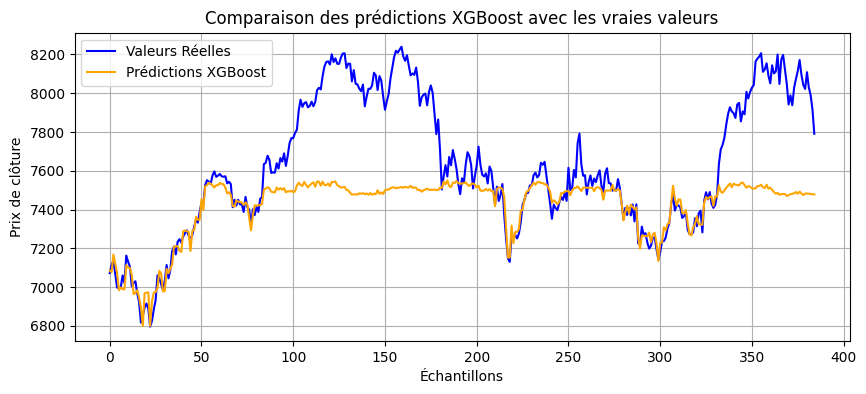

In [16]:
# t = "NVDA_lt"
# # Chargement des données
# df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PPE/" + t + "_cleaned.csv")

df = data_long_terme("^FCHI")
keep_lt = ['High', 'Low', 'Open', 'Volume', 'Month_sin',
           'Month_cos', 'Day_sin', 'Day_cos', 'RSI', 'PPO', 'MACD', 'Signal',
           'OBV', 'ROC']


# Normalisation des données
X = np.array(df.loc[:, keep_lt])
y = np.array(df["Close"]).reshape((-1, 1))
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Séparation des données
test_size = int(len(X) * 0.1)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# Création du modèle XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=3)
xgb_model.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# Calcul du RMSE pour XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

# Inverse transformation pour ramener les valeurs dans l'échelle originale
y_test_inverse = scaler_y.inverse_transform(y_test)
y_pred_inverse = scaler_y.inverse_transform(y_pred_xgb.reshape(-1, 1))

# Affichage des courbes
plt.figure(figsize=(10, 4))
plt.plot(y_test_inverse, label="Valeurs Réelles", color='blue')
plt.plot(y_pred_inverse, label="Prédictions XGBoost", color='orange')
plt.title("Comparaison des prédictions XGBoost avec les vraies valeurs")
plt.xlabel("Échantillons")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.show()

XGBoost (Court terme)

<ipython-input-12-79cd0a7ffafe>:137: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['direction'].iloc[0] = 0  # Set the direction of the first row to 0
<ipython-input-12-79cd0a7ffafe>:137: SettingWithCopyWarning: 
A value is trying to be s

XGBoost RMSE: 0.013219152685996053


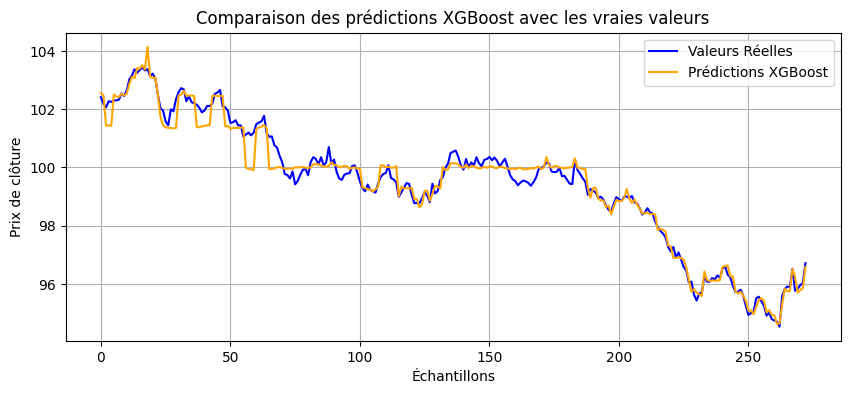

In [13]:
df = data_court_terme("NVDA")

keep_ct = ['Open', 'High', 'Low', 'Volume', 'Hour_sin',
           'Hour_cos', 'Minute_sin', 'Minute_cos', 'Day_sin', 'Day_cos', 'RSI',
           'PPO', 'MACD', 'Signal', 'OBV', 'ROC']

# Normalisation des données
X = np.array(df.loc[:, keep_ct])
y = np.array(df["Close"]).reshape((-1, 1))
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Séparation des données
test_size = int(len(X) * 0.1)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# Création du modèle XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=3)
xgb_model.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# Calcul du RMSE pour XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

# Inverse transformation pour ramener les valeurs dans l'échelle originale
y_test_inverse = scaler_y.inverse_transform(y_test)
y_pred_inverse = scaler_y.inverse_transform(y_pred_xgb.reshape(-1, 1))

# Affichage des courbes
plt.figure(figsize=(10, 4))
plt.plot(y_test_inverse, label="Valeurs Réelles", color='blue')
plt.plot(y_pred_inverse, label="Prédictions XGBoost", color='orange')
plt.title("Comparaison des prédictions XGBoost avec les vraies valeurs")
plt.xlabel("Échantillons")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.show()

## LSTM (Court Terme)

<ipython-input-12-79cd0a7ffafe>:137: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['direction'].iloc[0] = 0  # Set the direction of the first row to 0
<ipython-input-12-79cd0a7ffafe>:137: SettingWithCopyWarning: 
A value is trying to be s

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0381
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 6.1765e-04
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 6.0331e-04
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 4.3096e-04
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 4.5927e-04
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 3.7244e-04
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 4.3517e-04
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 3.5973e-04
Epoch 9/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 4.2283e-04
Epoch 10/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 3.8511e-04
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
RMSE: 0.7409


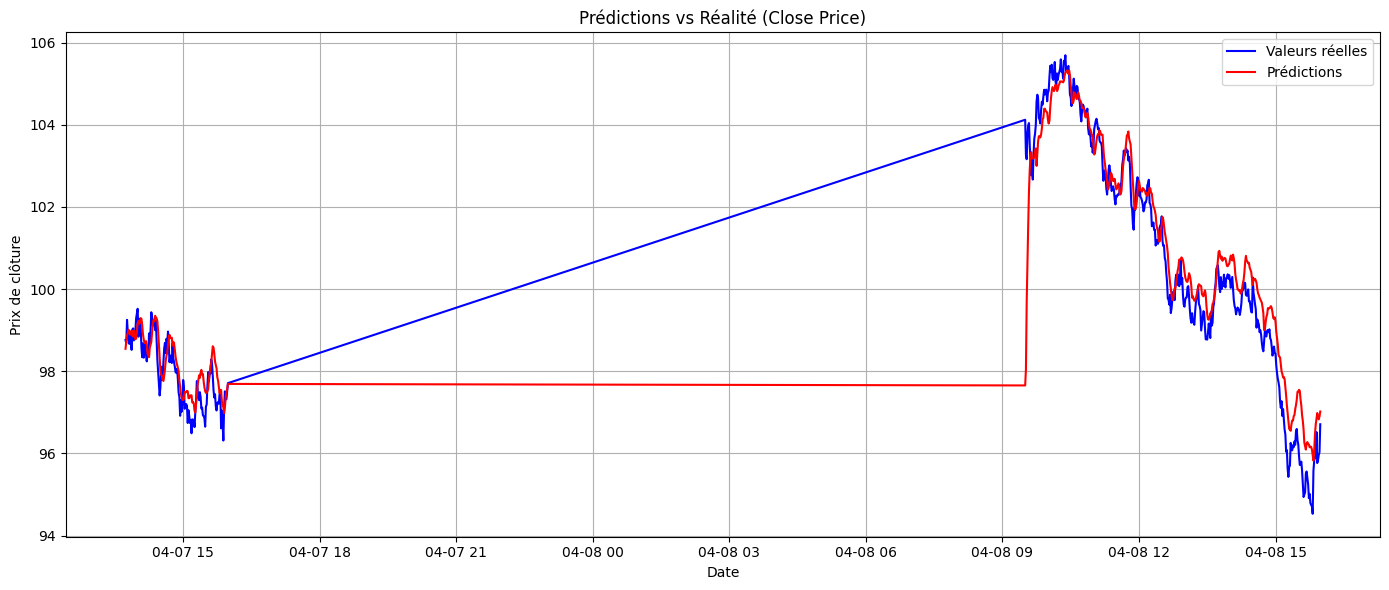

In [15]:

t = "ct"
# Chargement des données
df = data_court_terme("NVDA")
df['Date'] = pd.to_datetime(df['Date'])  # S'assure que les dates sont bien datées
df.set_index('Date', inplace=True)       # Met les dates en index

keep_lt = ['High', 'Low', 'Open', 'Volume', 'Month_sin',
       'Month_cos', 'Day_sin', 'Day_cos', 'RSI', 'PPO', 'MACD', 'Signal',
       'OBV', 'ROC']

keep_ct = ['Open', 'High', 'Low', 'Volume', 'Hour_sin',
       'Hour_cos', 'Minute_sin', 'Minute_cos', 'Day_sin', 'Day_cos', 'RSI',
       'PPO', 'MACD', 'Signal', 'OBV', 'ROC']

# Normalisation des données
keep_columns = {
    "lt": keep_lt,
    "ct": keep_ct,
}

X = np.array(df.loc[:, keep_columns[t]])
y = np.array(df["Close"]).reshape((-1, 1))
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Création des fenêtres temporelles
def create_time_windows(data, window_size):
    windows = [data[i:i + window_size] for i in range(len(data) - window_size)]
    return np.array(windows)

window_size = 100
X = create_time_windows(X, window_size)
y = y[window_size:]

# Séparation des données
test_size = int(len(X) * 0.2)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# FIX ICI :
test_dates = df.index[-len(y_test):]

# Création du modèle initial
model = Sequential([
    LSTM(100, activation='tanh', return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=20)

# Prédictions
y_pred = model.predict(X_test)
y_pred_real = scaler_y.inverse_transform(y_pred)
y_test_real = scaler_y.inverse_transform(y_test)

# Calcul du RMSE
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
print(f"RMSE: {rmse:.4f}")

# Affichage des courbes de prédiction vs. vraies valeurs
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_real, label='Valeurs réelles', color='blue')
plt.plot(test_dates, y_pred_real, label='Prédictions', color='red')
plt.title("Prédictions vs Réalité (Close Price)")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## LSTM (Long terme)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0017
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 1.9634e-05
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.4703e-05
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 1.2065e-05
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 1.0100e-05
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 1.1619e-05
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 1.4991e-05
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 1.4067e-05
Epoch 9/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 1.3075e-05
Epoch 10/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 1.5688e-05
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
RMSE: 4.4887


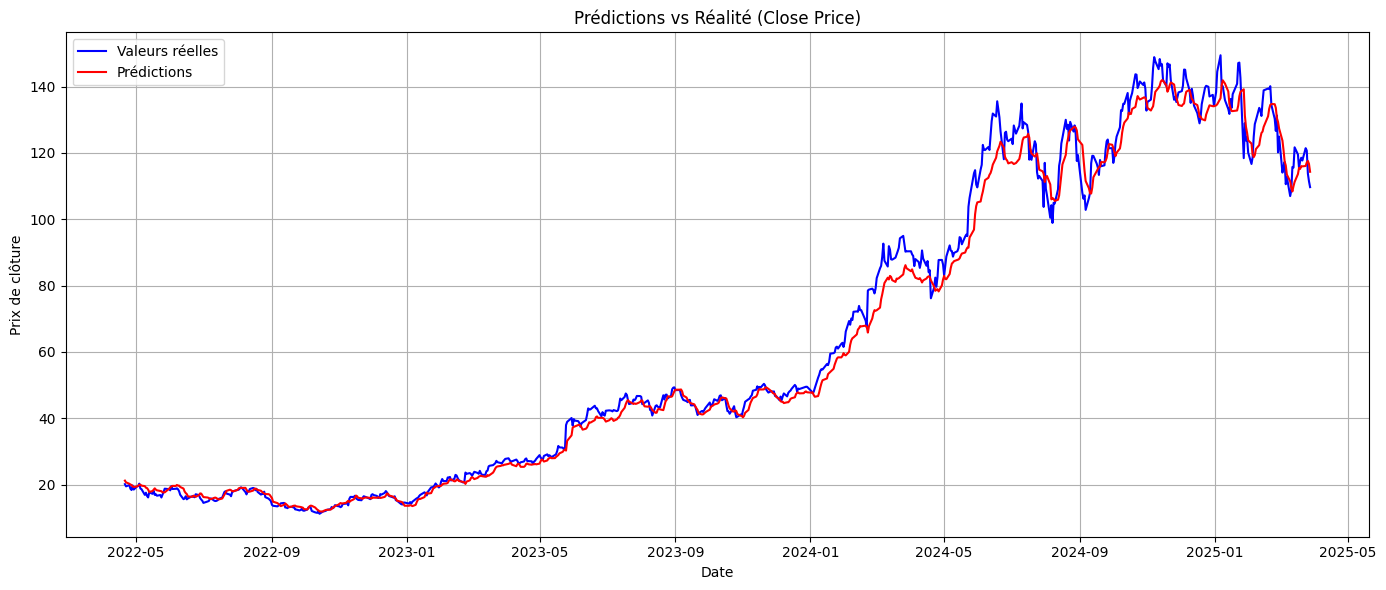

In [ ]:
t = "lt"
# Chargement des données
df = data_long_terme("NVDA")
df['Date'] = pd.to_datetime(df['Date'])  # S'assure que les dates sont bien datées
df.set_index('Date', inplace=True)       # Met les dates en index

keep_lt = ['High', 'Low', 'Open', 'Volume', 'Month_sin',
       'Month_cos', 'Day_sin', 'Day_cos', 'RSI', 'PPO', 'MACD', 'Signal',
       'OBV', 'ROC']

keep_ct = ['Open', 'High', 'Low', 'Volume', 'Hour_sin',
       'Hour_cos', 'Minute_sin', 'Minute_cos', 'Day_sin', 'Day_cos', 'RSI',
       'PPO', 'MACD', 'Signal', 'OBV', 'ROC']

# Normalisation des données
keep_columns = {
    "lt": keep_lt,
    "ct": keep_ct,
}

X = np.array(df.loc[:, keep_columns[t]])
y = np.array(df["Close"]).reshape((-1, 1))
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Création des fenêtres temporelles
def create_time_windows(data, window_size):
    windows = [data[i:i + window_size] for i in range(len(data) - window_size)]
    return np.array(windows)

window_size = 100
X = create_time_windows(X, window_size)
y = y[window_size:]

# Séparation des données
test_size = int(len(X) * 0.2)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# FIX ICI :
test_dates = df.index[-len(y_test):]

# Création du modèle initial
model = Sequential([
    LSTM(100, activation='tanh', return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=20)

# Prédictions
y_pred = model.predict(X_test)
y_pred_real = scaler_y.inverse_transform(y_pred)
y_test_real = scaler_y.inverse_transform(y_test)

# Calcul du RMSE
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
print(f"RMSE: {rmse:.4f}")

# Affichage des courbes de prédiction vs. vraies valeurs
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_real, label='Valeurs réelles', color='blue')
plt.plot(test_dates, y_pred_real, label='Prédictions', color='red')
plt.title("Prédictions vs Réalité (Close Price)")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
